# Complete Quality Filter Diagnostic (Save + ReID + Offline Refine)
This notebook lets you inspect a crop folder and understand **exactly** which quality gate rejects each crop.

**Usage:**
1. Set `CROP_FOLDER` to a person folder (e.g., `outputs/step2_global_crops_fixed/person_002`).
2. Set `FRAME_WIDTH` and `FRAME_HEIGHT` to your original camera resolution.
3. (Optional) Override any threshold; set to `None` to use the value from `config.py`.
4. Run all cells – you will see histograms, a summary table, and a grid of crops coloured by filter outcome.

In [3]:
# ========== EDIT THESE ==========
CROP_FOLDER = "outputs/test3/refined_v1/person_016"   # path to a person folder
FRAME_WIDTH  = 1280   # original video width
FRAME_HEIGHT = 720    # original video height

# Override thresholds (None = use config.py value)
# --- Saving quality gates ---
SAVE_MIN_WIDTH        = None
SAVE_MIN_HEIGHT       = None
SAVE_MIN_AREA_RATIO   = None   # e.g., 0.0010
SAVE_MIN_SHARPNESS    = None   # e.g., 8.0

# --- ReID quality gates (used online) ---
REID_MIN_WIDTH        = None
REID_MIN_HEIGHT       = None
REID_MIN_AREA_RATIO   = None   # e.g., 0.0012
REID_MIN_SHARPNESS    = None   # e.g., 12.0

# --- Offline refinement Stage A filters ---
REFINE_MIN_AREA_RATIO = None   # e.g., 0.0012
REFINE_MIN_SHARPNESS  = None   # e.g., 12.0
REFINE_MAX_ASPECT     = None   # e.g., 3.5 (0 = disabled)
# ==================================

In [4]:
import sys, os
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import OrderedDict


# Option A: point directly to the reid_system folder
project_root = Path.cwd() / "reid_system"
if not (project_root / "config.py").exists():
    # If you ran the notebook from reid_system/experiments
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config


# Resolve thresholds: use overrides if set, otherwise config
def get_thresh(override, config_attr):
    return override if override is not None else getattr(config, config_attr)

SAVE_MIN_WIDTH        = get_thresh(SAVE_MIN_WIDTH,        'MIN_WIDTH')
SAVE_MIN_HEIGHT       = get_thresh(SAVE_MIN_HEIGHT,       'MIN_HEIGHT')
SAVE_MIN_AREA_RATIO   = get_thresh(SAVE_MIN_AREA_RATIO,   'MIN_AREA_RATIO')
SAVE_MIN_SHARPNESS    = get_thresh(SAVE_MIN_SHARPNESS,    'MIN_SHARPNESS')

REID_MIN_WIDTH        = get_thresh(REID_MIN_WIDTH,        'MIN_REID_WIDTH')
REID_MIN_HEIGHT       = get_thresh(REID_MIN_HEIGHT,       'MIN_REID_HEIGHT')
REID_MIN_AREA_RATIO   = get_thresh(REID_MIN_AREA_RATIO,   'MIN_REID_AREA_RATIO')
REID_MIN_SHARPNESS    = get_thresh(REID_MIN_SHARPNESS,    'MIN_REID_SHARPNESS')

REFINE_MIN_AREA_RATIO = get_thresh(REFINE_MIN_AREA_RATIO, 'REFINE_MIN_REID_AREA_RATIO')
REFINE_MIN_SHARPNESS  = get_thresh(REFINE_MIN_SHARPNESS,  'REFINE_MIN_REID_SHARPNESS')
REFINE_MAX_ASPECT     = get_thresh(REFINE_MAX_ASPECT,     'REFINE_MAX_ASPECT_RATIO')

# Print all thresholds being used
print("Current thresholds:")
print(f"  SAVE:   width>={SAVE_MIN_WIDTH}, height>={SAVE_MIN_HEIGHT}, area>={SAVE_MIN_AREA_RATIO:.4f}, sharp>={SAVE_MIN_SHARPNESS}")
print(f"  REID:   width>={REID_MIN_WIDTH}, height>={REID_MIN_HEIGHT}, area>={REID_MIN_AREA_RATIO:.4f}, sharp>={REID_MIN_SHARPNESS}")
print(f"  REFINE: area>={REFINE_MIN_AREA_RATIO:.4f}, sharp>={REFINE_MIN_SHARPNESS}, aspect<={REFINE_MAX_ASPECT if REFINE_MAX_ASPECT>0 else 'disabled'}")

Current thresholds:
  SAVE:   width>=10, height>=20, area>=0.0010, sharp>=8.0
  REID:   width>=10, height>=20, area>=0.0012, sharp>=12.0
  REFINE: area>=0.0012, sharp>=12.0, aspect<=4.0


In [5]:
folder = Path(CROP_FOLDER)
if not folder.is_absolute():
    # Allow paths relative to project_root when running from reid_system/experiments
    candidate = project_root / folder
    if candidate.exists():
        folder = candidate
if not folder.exists():
    raise FileNotFoundError(f"Folder not found: {folder}")

img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
img_paths = sorted([p for p in folder.iterdir() if p.suffix.lower() in img_exts])
print(f"Found {len(img_paths)} images in {folder.name}")

# Compute metrics
metrics = []
for p in img_paths:
    img = cv2.imread(str(p))
    if img is None:
        continue
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sharp = cv2.Laplacian(gray, cv2.CV_32F).var()
    area_ratio = (w * h) / (FRAME_WIDTH * FRAME_HEIGHT)
    aspect = max(w, h) / max(1, min(w, h))
    metrics.append({
        'path': p, 'img': img, 'w': w, 'h': h,
        'sharpness': sharp, 'area_ratio': area_ratio, 'aspect_ratio': aspect
    })

print(f"Valid images loaded: {len(metrics)}")

# Define filter sets
filters = OrderedDict()
filters['save_width']   = ('Save width',   lambda m: m['w'] >= SAVE_MIN_WIDTH)
filters['save_height']  = ('Save height',  lambda m: m['h'] >= SAVE_MIN_HEIGHT)
filters['save_area']    = ('Save area',    lambda m: m['area_ratio'] >= SAVE_MIN_AREA_RATIO)
filters['save_sharp']   = ('Save sharp',   lambda m: m['sharpness'] >= SAVE_MIN_SHARPNESS)
filters['reid_width']   = ('ReID width',   lambda m: m['w'] >= REID_MIN_WIDTH)
filters['reid_height']  = ('ReID height',  lambda m: m['h'] >= REID_MIN_HEIGHT)
filters['reid_area']    = ('ReID area',    lambda m: m['area_ratio'] >= REID_MIN_AREA_RATIO)
filters['reid_sharp']   = ('ReID sharp',   lambda m: m['sharpness'] >= REID_MIN_SHARPNESS)
filters['refine_area']  = ('Refine area',  lambda m: m['area_ratio'] >= REFINE_MIN_AREA_RATIO)
filters['refine_sharp'] = ('Refine sharp', lambda m: m['sharpness'] >= REFINE_MIN_SHARPNESS)
if REFINE_MAX_ASPECT > 0:
    filters['refine_aspect'] = ('Refine aspect', lambda m: m['aspect_ratio'] <= REFINE_MAX_ASPECT)

# Evaluate each crop against all filters
for m in metrics:
    m['results'] = {}
    for fkey, (fname, fn) in filters.items():
        m['results'][fkey] = fn(m)

# Summary counts
print("\nFilter pass counts:")
for fkey, (fname, _) in filters.items():
    passed = sum(1 for m in metrics if m['results'][fkey])
    failed = len(metrics) - passed
    print(f"  {fname:15s}  passed: {passed:3d}  failed: {failed:3d}")

# Overall pass (all filters)
overall_pass = [m for m in metrics if all(m['results'].values())]
print(f"\nCrops passing ALL filters: {len(overall_pass)} out of {len(metrics)}")

Found 193 images in person_016
Valid images loaded: 193

Filter pass counts:
  Save width       passed: 193  failed:   0
  Save height      passed: 193  failed:   0
  Save area        passed: 193  failed:   0
  Save sharp       passed: 193  failed:   0
  ReID width       passed: 193  failed:   0
  ReID height      passed: 193  failed:   0
  ReID area        passed: 193  failed:   0
  ReID sharp       passed: 193  failed:   0
  Refine area      passed: 193  failed:   0
  Refine sharp     passed: 193  failed:   0
  Refine aspect    passed: 193  failed:   0

Crops passing ALL filters: 193 out of 193


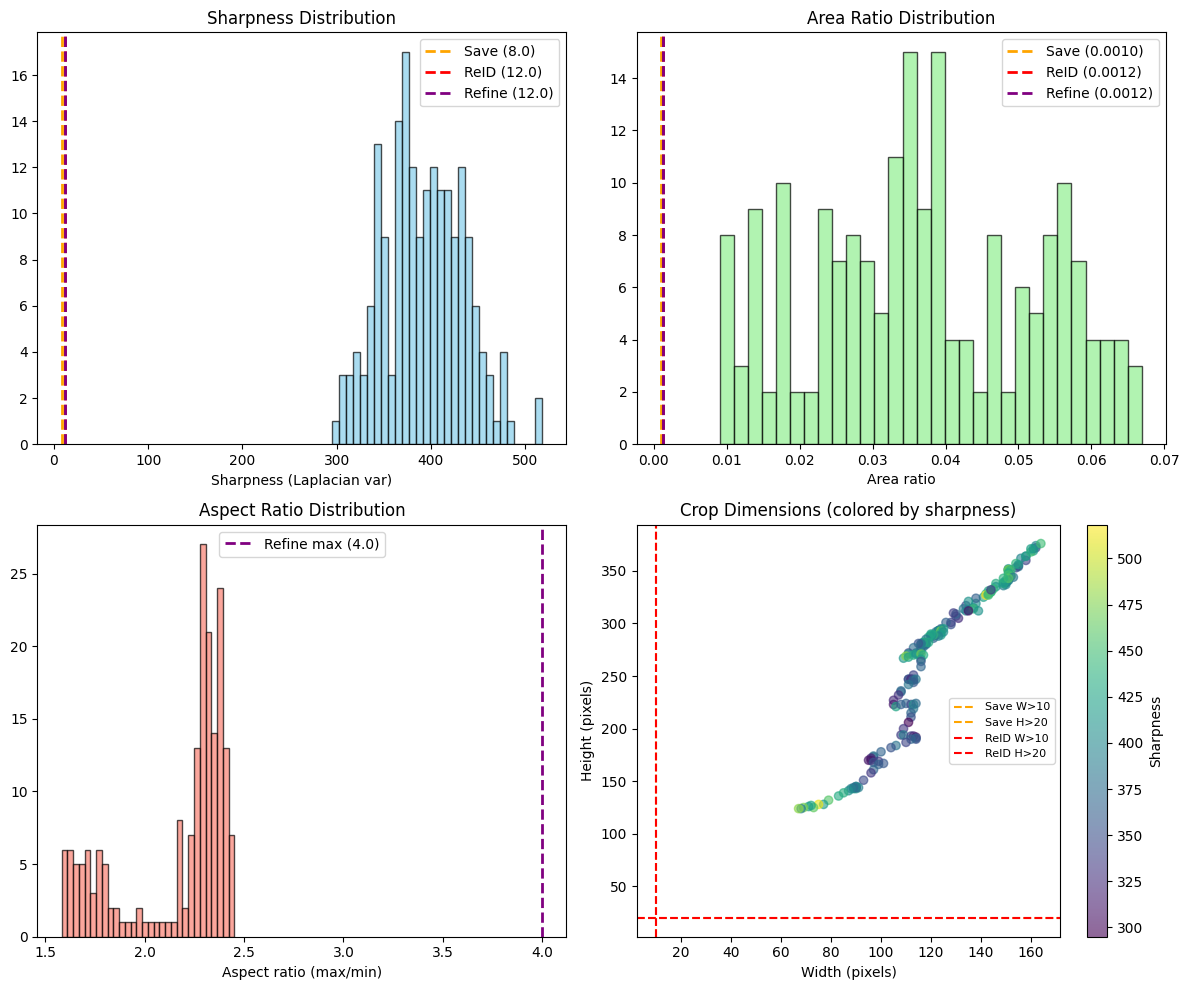

In [6]:
# Histograms with thresholds for main continuous metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sharpness
ax = axes[0,0]
sharps = [m['sharpness'] for m in metrics]
ax.hist(sharps, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(SAVE_MIN_SHARPNESS, color='orange', linestyle='--', linewidth=2, label=f'Save ({SAVE_MIN_SHARPNESS})')
ax.axvline(REID_MIN_SHARPNESS, color='red', linestyle='--', linewidth=2, label=f'ReID ({REID_MIN_SHARPNESS})')
ax.axvline(REFINE_MIN_SHARPNESS, color='purple', linestyle='--', linewidth=2, label=f'Refine ({REFINE_MIN_SHARPNESS})')
ax.set_xlabel('Sharpness (Laplacian var)')
ax.set_title('Sharpness Distribution')
ax.legend()

# Area ratio
ax = axes[0,1]
areas = [m['area_ratio'] for m in metrics]
ax.hist(areas, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(SAVE_MIN_AREA_RATIO, color='orange', linestyle='--', linewidth=2, label=f'Save ({SAVE_MIN_AREA_RATIO:.4f})')
ax.axvline(REID_MIN_AREA_RATIO, color='red', linestyle='--', linewidth=2, label=f'ReID ({REID_MIN_AREA_RATIO:.4f})')
ax.axvline(REFINE_MIN_AREA_RATIO, color='purple', linestyle='--', linewidth=2, label=f'Refine ({REFINE_MIN_AREA_RATIO:.4f})')
ax.set_xlabel('Area ratio')
ax.set_title('Area Ratio Distribution')
ax.legend()

# Aspect ratio
ax = axes[1,0]
aspects = [m['aspect_ratio'] for m in metrics]
ax.hist(aspects, bins=30, color='salmon', edgecolor='black', alpha=0.7)
if REFINE_MAX_ASPECT > 0:
    ax.axvline(REFINE_MAX_ASPECT, color='purple', linestyle='--', linewidth=2, label=f'Refine max ({REFINE_MAX_ASPECT})')
ax.set_xlabel('Aspect ratio (max/min)')
ax.set_title('Aspect Ratio Distribution')
ax.legend()

# Width vs Height scatter
ax = axes[1,1]
ws = [m['w'] for m in metrics]
hs = [m['h'] for m in metrics]
sc = ax.scatter(ws, hs, c=[m['sharpness'] for m in metrics], cmap='viridis', alpha=0.6)
plt.colorbar(sc, ax=ax, label='Sharpness')
# Save thresholds
ax.axvline(SAVE_MIN_WIDTH, color='orange', linestyle='--', label=f'Save W>{SAVE_MIN_WIDTH}')
ax.axhline(SAVE_MIN_HEIGHT, color='orange', linestyle='--', label=f'Save H>{SAVE_MIN_HEIGHT}')
# ReID thresholds
ax.axvline(REID_MIN_WIDTH, color='red', linestyle='--', label=f'ReID W>{REID_MIN_WIDTH}')
ax.axhline(REID_MIN_HEIGHT, color='red', linestyle='--', label=f'ReID H>{REID_MIN_HEIGHT}')
ax.set_xlabel('Width (pixels)')
ax.set_ylabel('Height (pixels)')
ax.set_title('Crop Dimensions (colored by sharpness)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

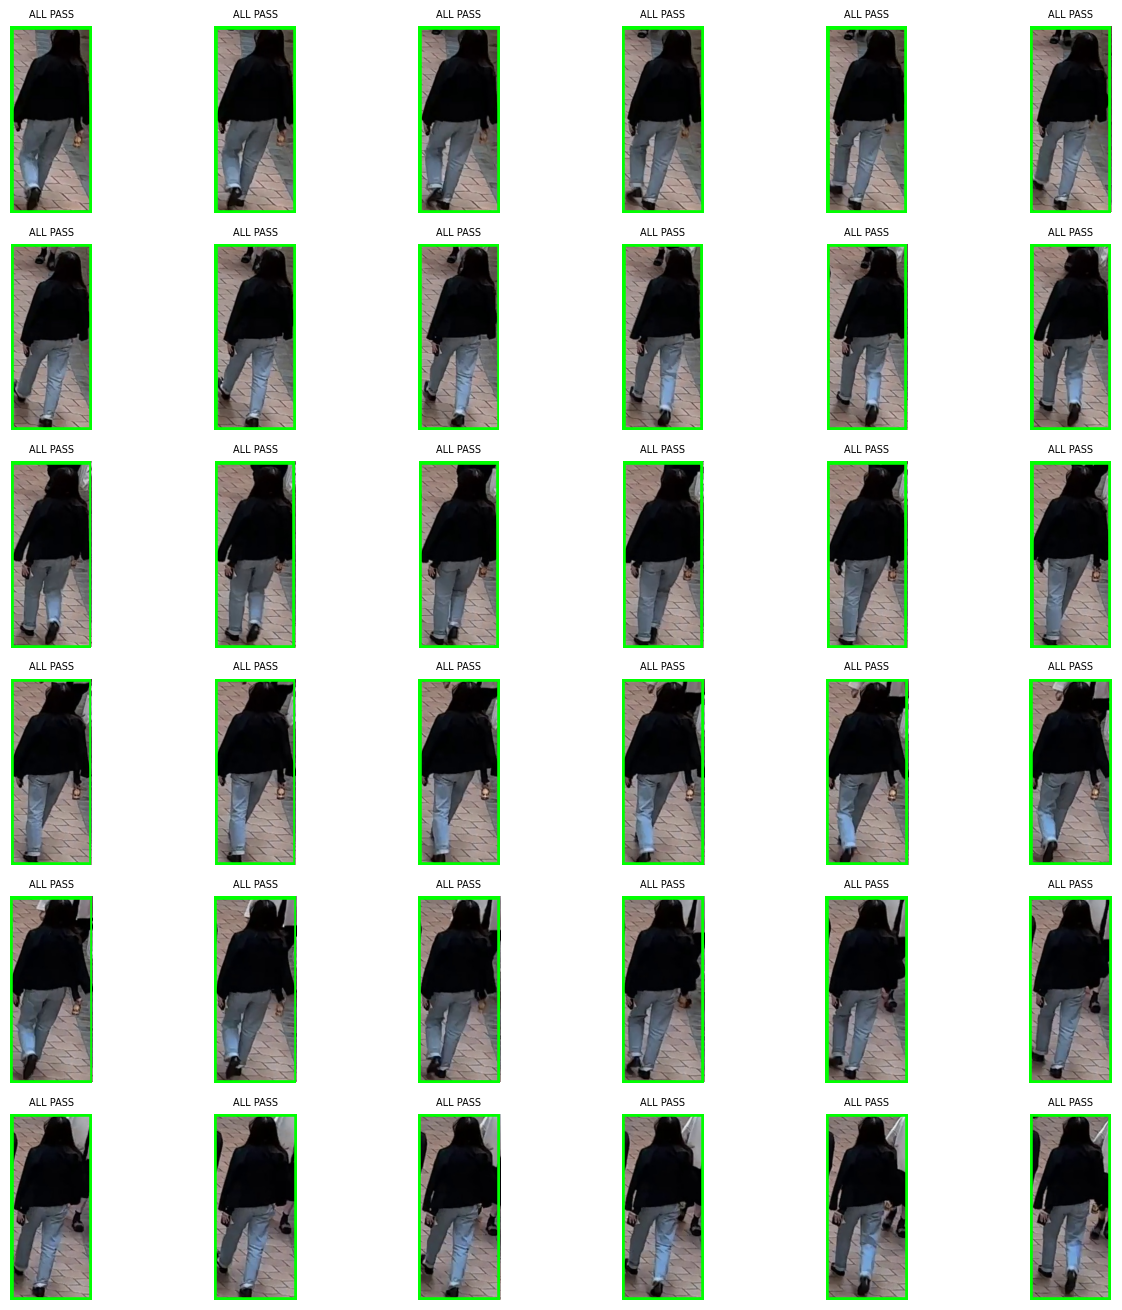

In [7]:
# Visual grid: show a selection of crops with colored borders indicating filter status.
# Green  = pass ALL filters
# Yellow = pass some but not all (show failed filters in title)
# Red    = fail ALL filters

def color_for_crop(m):
    passed = sum(m['results'].values())
    total = len(m['results'])
    if passed == total:
        return (0, 255, 0)      # green
    elif passed == 0:
        return (255, 0, 0)      # red
    else:
        return (255, 200, 0)    # orange / yellow

def failed_filters_str(m):
    failed = [fname for fkey, (fname, _) in filters.items() if not m['results'][fkey]]
    return ", ".join(failed) if failed else "ALL PASS"

# We'll show up to 30 crops (or all if fewer)
show_metrics = metrics[:36]  # limit to avoid huge figure
n = len(show_metrics)
cols = 6
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, m in enumerate(show_metrics):
    ax = axes[i]
    img_rgb = cv2.cvtColor(m['img'], cv2.COLOR_BGR2RGB)
    border_color = color_for_crop(m)
    # Add colored border by drawing a rectangle around the image
    ax.imshow(img_rgb)
    rect = Rectangle((0, 0), img_rgb.shape[1], img_rgb.shape[0],
                     linewidth=4, edgecolor=np.array(border_color)/255.0, facecolor='none')
    ax.add_patch(rect)
    ax.set_title(failed_filters_str(m), fontsize=7)
    ax.axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### How to interpret the grid
- **Green border** = crop passes all filters (Save, ReID, Refine).
- **Orange border** = crop passes some filters but fails others – the failed filter names are shown in the title.
- **Red border** = crop fails every filter.

### Next steps
- Adjust the thresholds in the first cell and re‑run to see how the pass rate changes.
- Once you’re satisfied, copy the chosen values into `config.py` and re‑run the full pipeline.